In [ ]:
"""
This notebook does:
1. Build a Random Rorest classifer for baseline picoplankton province prediction
2. Evaluate model performance using repeated stratified cross-validation and confusion matrixs
3. Apply the trained model to predict province distribution under future environmental scenarios
4. Visualize predicted provinces on global maps and generate diagnostic plots (heatmap: accuracy & boxplot: feature importances)
5. Quantify province changes using transition matrices and summary tables of changed points (summary table & transition matrix)

Only sample data were used for analyses.
"""

In [ ]:
! ls /data/gpfs/projects/punim2700/data/share

In [ ]:
! ls ../data/share/sample_scenarios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colors
import os

In [ ]:
! which python

In [2]:
sample_metadata = pd.read_csv("../data/share/sample_metadata.csv", index_col=0)
y = sample_metadata["picoplankton_province"]

In [3]:
baseline_samples = pd.read_csv("../data/share//sample_scenarios/baseline_samples.csv", index_col="index")
X = baseline_samples

In [4]:
# remove redundant variables from the baseline X
columns_to_remove1 = ['DiffuseAttenuationCoefficientPAR', 'MixedLayerDepth', 'SeaWaterSpeed', 'PhotosyntheticallyAvailableRadiation', 'Terrain']
X = X[[col for col in X.columns if col not in columns_to_remove1]]

# remove non-used environmental variables from X
columns_to_remove2 = ['AirTemperature', 'SeaIceThickness', 'TotalCloudFraction', 'TotalPhytoplankton']
X = X[[col for col in X.columns if col not in columns_to_remove2]]


In [5]:
# build a Random Forest classifier
def build_clf_model(variables_to_omit):
    X_ = X.copy()
    
    # temporarily remove SSP-specific missing variables
    if variables_to_omit:
        X_ = X.drop(variables_to_omit, axis=1)
        
    random_state = 4
    test_size = 0.2
    X_train, X_test, y_train, y_test = train_test_split(
        X_, y, test_size=test_size, random_state=random_state, stratify=y
    )
    clf = RandomForestClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    confusion = pd.DataFrame(
        confusion_matrix(y_test, y_pred), index=clf.classes_,columns=clf.classes_
    )
    return clf, y_pred, accuracy, confusion


In [6]:
clf, y_pred, accuracy, confusion = build_clf_model(None)
confusion

,APLR,BALT,BPLR,CTEM,MTEM,OTEM,STEM,TGYR,TRHI,TRLO
APLR,6,0,0,0,0,0,0,0,0,0
BALT,0,10,0,0,0,0,0,0,0,0
BPLR,0,1,5,0,0,2,0,0,0,0
CTEM,0,0,0,28,0,0,0,0,0,0
MTEM,0,0,0,0,15,1,0,0,0,0
OTEM,0,0,0,0,0,9,0,0,0,0
STEM,0,0,0,0,0,4,3,0,0,0
TGYR,0,0,0,0,0,0,1,31,0,0
TRHI,0,0,0,0,0,0,0,0,11,0
TRLO,0,0,0,0,0,0,0,0,0,164


In [7]:
# repeated stratified k-fold CV to assess RF stability
cv = RepeatedStratifiedKFold(n_splits=9, n_repeats=10, random_state=4)
confusion_matrices, accuracies = [], []
feature_importances = []

In [8]:
for i, (train_index, test_index) in enumerate(cv.split(X,y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the classifier
    clf.fit(X_train, y_train)

    # Predict the test set
    y_pred = clf.predict(X_test)
    confusion_mat = confusion_matrix(y_test, y_pred, normalize="pred")
    confusion_matrices.append(confusion_mat)

    # Evaluate the performance
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Get the feature importanes
    feature_importances.append(clf.feature_importances_)
    

In [9]:
confusion = np.mean(np.stack(confusion_matrices), axis=0)
confusion = pd.DataFrame(confusion, index=clf.classes_, columns=clf.classes_)

confusion_sd = np.std(np.stack(confusion_matrices), axis=0)
confusion_sd = pd.DataFrame(confusion_sd, index=clf.classes_, columns=clf.classes_)

In [10]:
# Per-class annotation text for diagonal cells
def create_annot_text(mean_df, sd_df):
    annot = mean_df.round(2).astype(str)
    for i in range(len(mean_df)):
        annot.iloc[i, i] += "±" + str(round(sd_df.iloc[i, i], 2))
    return annot

In [11]:
# Create annotation text
annot_text = create_annot_text(confusion, confusion_sd)   

Text(0.0, 1.0, 'Cross-validation strategy: repeated stratified $k$-fold. 9 splits, 10 repeats.')

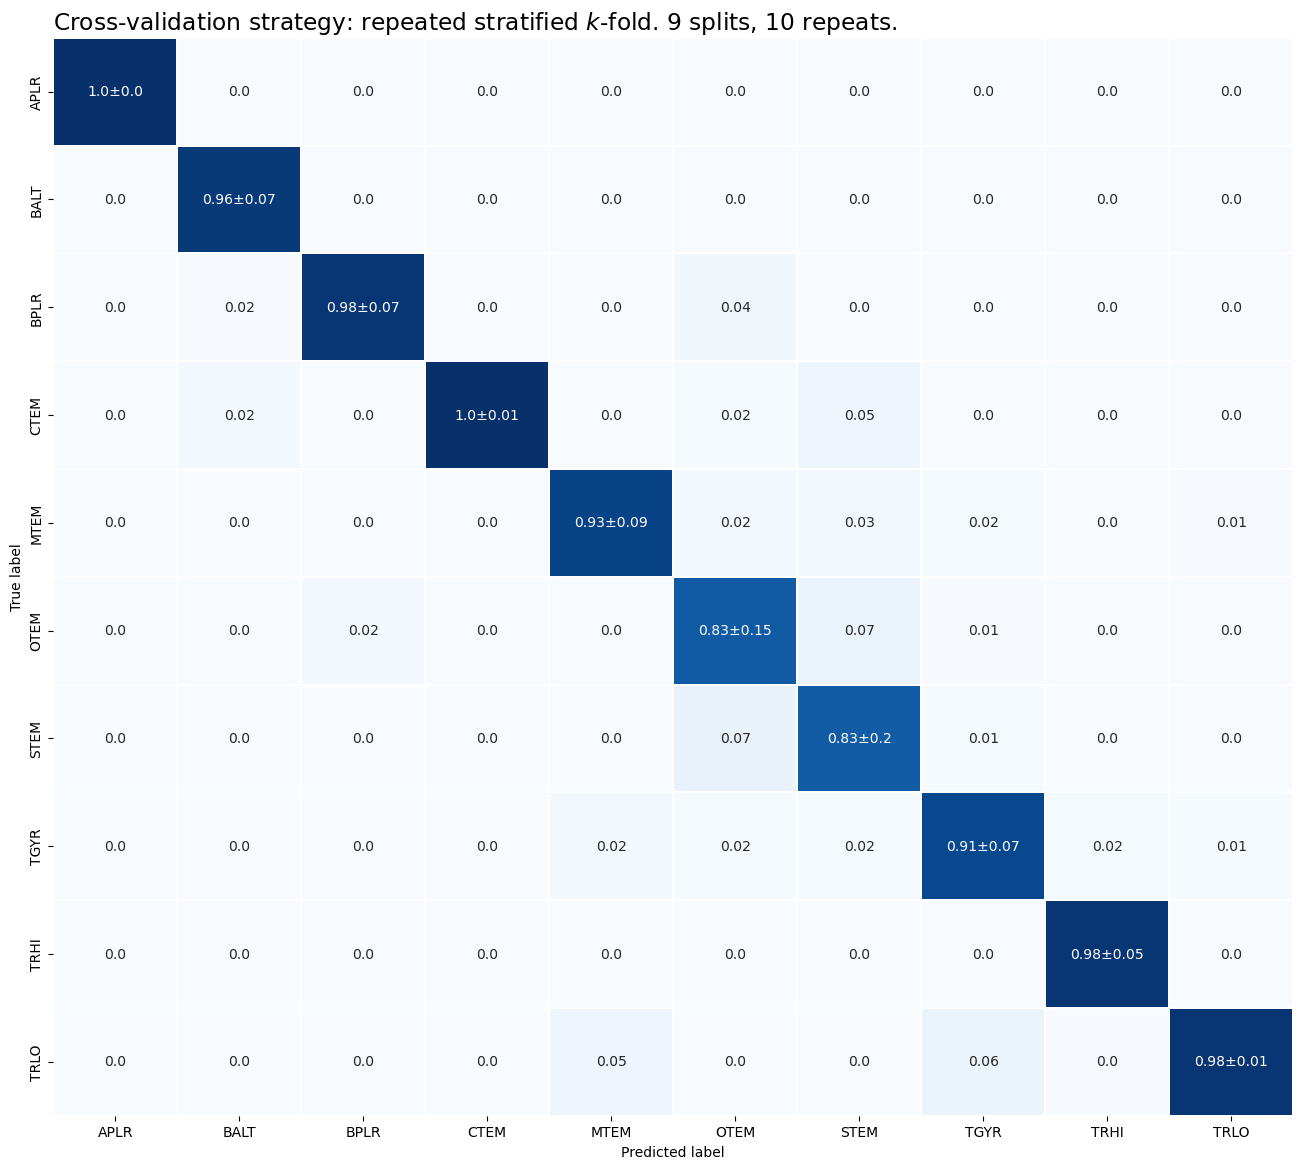

In [12]:
# plot heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.set(font_scale=1.4)
sns.heatmap(
    confusion,
    annot=annot_text,
    fmt="",
    cmap=plt.cm.Blues,
    linewidths=0.2,
    ax=ax,
    annot_kws={"size": 10},
    cbar=False
)

# Add labels
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "Cross-validation strategy: repeated stratified $k$-fold. 9 splits, 10 repeats.", 
    loc="left",
)

In [15]:
pd.DataFrame({"accuracy": accuracies, "cv_method": "repeated_stratified_kfold"}).to_csv(
    "../outputs/tables/sample/repeated_kfold_cv_scores.csv", index=False
)

In [ ]:
# get feature importance
def get_ordered_feature_importances(X, clf, feature_importances):
    feature_importances = pd.DataFrame(feature_importances)
    feature_importances.columns = clf.feature_names_in_
    
    feature_importances_order = (
        feature_importances.mean().sort_values(ascending=False).index
    )
    
    corr = X.corr()
    corr_order = corr.loc[feature_importances_order, feature_importances_order]

    return corr_order, feature_importances, feature_importances_order
    

In [ ]:
corr_order, feature_importances, feature_importances_order = get_ordered_feature_importances(X, clf, feature_importances)


In [ ]:
# plot feature importance
fig, axs = plt.subplots(2, 1, figsize=(16, 24))
sns. boxplot(
    data=feature_importances[feature_importances_order],
    palette="Blues_r",
    orient="h",
    ax=axs[0],
)
axs[0].set_xlabel("Feature relative importance")
axs[0].set_title("Feature importance across 100 folds of cross-validation")
sns.heatmap(corr_order, cmap="coolwarm_r", annot=True, fmt=".2f", ax=axs[1])
axs[1].set_title("Correlation between predictor features")

plt.annotate("A", (0.05, 0.875), xycoords="figure fraction", weight="bold", size=16)
plt.annotate("B", (0.05, 0.475), xycoords="figure fraction", weight="bold", size=16)

plt.savefig(f"../outputs/figures/sample_feature_importance_correlation.svg", bbox_inches="tight")


In [ ]:
sample_metadata = pd.read_csv("../data/share/sample_metadata.csv", index_col=0)
Y = sample_metadata

In [ ]:
# future scenarios
SSP_file = {
    "SSP119" : "SSP119_samples.csv",
    "SSP126" : "SSP126_samples.csv",
    "SSP245" : "SSP245_samples.csv",
    "SSP370" : "SSP370_samples.csv",
    "SSP460" : "SSP460_samples.csv",
    "SSP585" : "SSP585_samples.csv",
}


In [ ]:
# predict ssp provinces
def sample_ssp_predictions(SSP_file, Y):
    os.makedirs("../outputs/sample_province_predictions", exist_ok=True)
    
    for ssp, fname in SSP_file.items():
        X_future = pd.read_csv(
            f"../data/share/sample_scenarios/{fname}", 
            index_col="index"
        )
        
        if ssp == "SSP245":
            features_to_omit = ["Nitrate"]
        else:
            features_to_omit = None
            
        clf, _, _, _ = build_clf_model(features_to_omit)
        X_future = X_future[clf.feature_names_in_]
        y_pred_future = clf.predict(X_future)
    
        # add predicted province to dataframe
        Y_future = Y.copy()
        Y_future["province_pred"] = pd.Series(
            y_pred_future, 
            index=X_future.index
        )

        # find the changed points
        Y_future["changed"] = (
            Y_future["province_pred"] != Y_future["picoplankton_province"]
        )

        # save preditions as CSVs
        df_save = Y_future[["province_pred", "changed"]]
        
        df_save.to_csv(
            f"../outputs/sample_province_predictions/sample_{ssp}_province_predictions.csv"
        )

        print(f"{ssp} done.")


In [ ]:
sample_ssp_predictions(SSP_file, Y)

In [ ]:
# construct a unified prediction table
def build_all_pred_from_csv(SSP_file, Y):
    all_pred = Y[["picoplankton_province", "longitude", "latitude"]].copy()
    
    for ssp in SSP_file.keys():
        df_pred = pd.read_csv(
            f"../outputs/sample_province_predictions/sample_{ssp}_province_predictions.csv",
            index_col=0,
        )
        all_pred[f"pred_{ssp}"] = df_pred["province_pred"]
        
    return all_pred
    

In [ ]:
# set provinces colour for plotting
provinces = sorted(Y["picoplankton_province"].unique())
colours = plt.cm.tab10.colors
province_colour = dict(zip(provinces, colours)) 

prov_to_id = {p: i for i, p in enumerate(provinces)}
cmap = colors.ListedColormap([province_colour[p] for p in provinces])
norm = colors.BoundaryNorm(
    np.arange(-0.5, len(provinces) + 0.5, 1),
    cmap.N
)


In [ ]:
# prepare predicted data
def load_ssp_predictions(ssp, Y):
    df_pred = pd.read_csv(
            f"../outputs/sample_province_predictions/sample_{ssp}_province_predictions.csv",
            index_col=0,
        )

    # reconstruct Y_future
    Y_future = Y.copy()
    Y_future[["province_pred", "changed"]] = df_pred[["province_pred", "changed"]]

    return Y_future


In [ ]:
# plot predicted provinces in points
def plot_ssp_points(ssp, Y):
    Y_future = load_ssp_predictions(ssp, Y)

    fig = plt.figure(figsize=(16,8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    
    for prov, df in Y_future.groupby("province_pred"): 
        ax.scatter(
            df["longitude"],
            df["latitude"],
            color=province_colour[prov], 
            label=prov,
            transform=ccrs.PlateCarree(),
        )

        dfc = Y_future[Y_future["changed"]]
        ax.scatter(
            dfc["longitude"],
            dfc["latitude"],
            facecolors="none", 
            edgecolors="black",
            linewidth=1.6,
            label="Changed vs Baseline",
            transform=ccrs.PlateCarree(),
        )
    
        ax.set_title(
            f"{ssp} predicted province", 
            size=15,
            loc="left",
        )

        fig.savefig(
            f"../outputs/figures/sample/sample_{ssp}_predicted_province.png"
        )


      

In [ ]:
for ssp in SSP_file.keys():
    plot_ssp_points(ssp, Y)

In [ ]:
# plot predicted provinces in surfaces
def plot_ssp_surface(ssp, Y, grid_res=1.0):
    Y_future = load_ssp_predictions(ssp, Y)
    
    # convert province to umeric id for gridded plot
    Y_future["prov_id"] = Y_future["province_pred"].map(prov_to_id)

    # build full ocean-surface grid 
    grid_df = 

    # build grid from data lon/lat
    lon_vals = np.sort(Y_future["longitude"].unique())
    lat_vals = np.sort(Y_future["latitude"].unique())

    def mode_or_first(x):
        m = x.mode()
        return m.iloc[0] if len(m) else x.iloc[0]

    grid = (
        Y_future
        .pivot_table(
            index="latitude", 
            columns="longitude", 
            values="prov_id",
            aggfunc=mode_or_first,
        )
        .reindex(index=lat_vals, columns=lon_vals)
    )

    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # atla base
    ax.set_global()
    ax.add_feature(
        cfeature.NaturalEarthFeature("physical", "land", "10m"),
        lw=0.5,
        alpha=1,
        color="#EFEFDB",
        zorder=2,
    )
    ax.add_feature(cfeature.LAKES, lw=0.5, zorder=2)
    ax.add_feature(cfeature.RIVERS, zorder=2)
    ax.coastlines(resolution="10m", lw=0.5, zorder=2)


    # surface grid
    ax.pcolormesh(
        lon_vals,
        lat_vals,
        grid.values,
        cmap=cmap,
        norm=norm,
        shading="nearest",
        transform=ccrs.PlateCarree(),
        rasterized=True,
        zorder=0,
    )

    # changed points overlayed
    dfc = Y_future[Y_future["changed"]]
    ax.scatter(
        dfc["longitude"],
        dfc["latitude"],
        facecolors="none",
        edgecolors="black",
        linewidth=1.0,
        s=10,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    ax.set_title(f"{ssp} predicted province", size=15, loc="left")
    os.makedirs("../outputs/figures", exist_ok=True)
    fig.savefig(
        f"../outputs/figures/sample_{ssp}_predicted_province_surface.png",
        dpi=300,
        bbox_inches="tight",
    )

In [ ]:
plot_ssp_surface("SSP245", Y)

In [ ]:
# Summarise province changes at sample locations across SSP scenarios
def summarise_ssp_changes(SSP_file, Y):
    all_pred = build_all_pred_from_csv(SSP_file, Y)
    
    ssp_list = list(SSP_file.keys())
    summary_rows = []
    n_total = len(all_pred)

    for ssp in ssp_list:
        n_changed = all_pred[f"pred_{ssp}"] != all_pred["picoplankton_province"]
        summary_rows.append({
            "SSP": ssp,
            "changed_points": int(n_changed.sum()),
            "total_points": n_total,
            "percent_changed": round(n_changed.sum() / n_total * 100, 2),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f"../outputs/tables/sample/summary_changed_points_by_ssp.csv", index=False)


In [ ]:
summary_df = pd.read_csv("../outputs/tables/sample/summary_changed_points_by_ssp.csv")
summary_df

In [ ]:
# province-to-province transition martix
all_pred = build_all_pred_from_csv(SSP_file, Y)
ssp_list = [
    col.replace("pred_", "") for col in all_pred.columns if col.startswith("pred_")
]
for ssp in ssp_list:
    trans_prop = pd.crosstab(
        all_pred["picoplankton_province"],
        all_pred[f"pred_{ssp}"],
        normalize="index",
    )

    trans_prop = trans_prop.round(3)
    trans_prop.to_csv(f"../outputs/tables/sample_{ssp}_predicted_province_transition.csv", index=False)

    display(trans_prop)


In [ ]:
# plot feature importance and predictor correlation

importance_summary = pd.DataFrame({
    "mean": feature_importances[feature_importances_order].mean(),
    "std": feature_importances[feature_importances_order].std()
})

importance_summary = importance_summary.loc[feature_importances_order]

fig, axs = plt.subplots(1, 2, figsize=(16, 7))


# A. Mean feature importance with variation across CV folds
axs[0].barh(
    importance_summary.index,
    importance_summary["mean"],
    xerr=importance_summary["std"],
    color="lightsteelblue",
    edgecolor="black",
    capsize=3
)

axs[0].invert_yaxis()
axs[0].set_xlabel("Mean relative importance")
axs[0].set_ylabel("")
axs[0].set_title("(a) Predictor contribution to province classification")
axs[0].grid(axis="x", alpha=0.25)


# B. Correlation network among predictors
features = list(corr_order.index)
n_features = len(features)

angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
x_pos = np.cos(angles)
y_pos = np.sin(angles)

positions = {
    feature: (x_pos[i], y_pos[i])
    for i, feature in enumerate(features)
}

corr_threshold = 0.5

for i in range(n_features):
    for j in range(i + 1, n_features):
        feature_i = features[i]
        feature_j = features[j]
        r = corr_order.loc[feature_i, feature_j]

        if abs(r) >= corr_threshold:
            x1, y1 = positions[feature_i]
            x2, y2 = positions[feature_j]

            if r > 0:
                line_color = "orangered"
            else:
                line_color = "royalblue"

            axs[1].plot(
                [x1, x2],
                [y1, y2],
                color=line_color,
                linewidth=abs(r) * 4,
                alpha=0.8
            )

axs[1].scatter(
    x_pos,
    y_pos,
    s=100,
    color="white",
    edgecolor="black",
    zorder=3
)

for feature in features:
    x, y = positions[feature]
    axs[1].text(
        x * 1.18,
        y * 1.18,
        feature,
        ha="center",
        va="center",
        fontsize=9
    )

axs[1].set_xlim(-1.2, 1.2)
axs[1].set_ylim(-1.2, 1.2)
axs[1].set_title("(b) Strong correlations among predictors")
axs[1].axis("off")

plt.tight_layout()

